# **Install and Import Package**


In [1]:
%pip install requests
%pip install matplotlib



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import requests
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
# Fix SSL certificate issue temporarily 
import ssl
import nltk
import re
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()
import time


# **Step 1: Crawl a Real-World Dataset**

In [3]:
import requests
import json
import numpy as np
import pandas as pd

In [4]:
subreddit = 'apple'
timeframe = 'year'   # hour, day, week, month, year, all
listing = 'top' # controversial, best, hot, new, random, rising, top
limit = 250    

In [5]:
def get_reddit(subreddit, listing, limit, timeframe):
    try:
        base_url = (
            f'https://www.reddit.com/r/{subreddit}/{listing}.json'
            f'?limit={limit}&t={timeframe}'
        )
        request = requests.get(base_url, headers={'User-agent': 'SDPA'})
    except Exception as e:
        print('An Error Occurred in get_reddit:', e)
        return None
    return request

def get_reddit_after(subreddit, listing, limit, timeframe, after_token):
    '''Get Reddit posts after a specific token (pagination).'''
    try:
        base_url = (
            f'https://www.reddit.com/r/{subreddit}/{listing}.json'
            f'?limit={limit}&t={timeframe}&after={after_token}'
        )
        request = requests.get(base_url, headers={'User-agent': 'SDPA'})
    except Exception as e:
        print('An Error Occurred in get_reddit_after:', e)
        return None
    return request

In [6]:
r = get_reddit(subreddit, listing, limit, timeframe)
data = json.loads(r.content)

temp = []
children = data['data']['children']
print('Page 1 posts:', len(children))

for i in range(len(children)):
    post = children[i]['data']
    temp.append([
        post['title'],
        post['ups'],
        post['link_flair_text'],
        post['num_comments'],
        post['selftext'],
        post['created_utc'],
        post['id']
    ])

top100 = pd.DataFrame(
    np.array(temp, dtype=object),
    columns=['Title', 'Upvotes', 'Flair', 'Num_Comments',
             'Body', 'Created_UTC', 'Post_ID']
)

#  2nd 100 posts 
after_token = data['data']['children'][len(children)-1]['kind'] + '_' + \
              data['data']['children'][len(children)-1]['data']['id']

r_new = get_reddit_after(subreddit, listing, limit, timeframe, after_token)
data_second = json.loads(r_new.content)

temp = []
children2 = data_second['data']['children']
print('Page 2 posts:', len(children2))

for i in range(min(100, len(children2))):
    post = children2[i]['data']
    temp.append([
        post['title'],
        post['ups'],
        post['link_flair_text'],
        post['num_comments'],
        post['selftext'],
        post['created_utc'],
        post['id']
    ])

top200 = pd.DataFrame(
    np.array(temp, dtype=object),
    columns=['Title', 'Upvotes', 'Flair', 'Num_Comments',
             'Body', 'Created_UTC', 'Post_ID']
)

#  3rd 
after_token_second = children2[len(children2)-1]['kind'] + '_' + \
                     children2[len(children2)-1]['data']['id']

r_new2 = get_reddit_after(subreddit, listing, limit, timeframe, after_token_second)
data_third = json.loads(r_new2.content)

temp = []
children3 = data_third['data']['children']
print('Page 3 posts:', len(children3))

for i in range(len(children3)):
    post = children3[i]['data']
    temp.append([
        post['title'],
        post['ups'],
        post['link_flair_text'],
        post['num_comments'],
        post['selftext'],
        post['created_utc'],
        post['id']
    ])

top250 = pd.DataFrame(
    np.array(temp, dtype=object),
    columns=['Title', 'Upvotes', 'Flair', 'Num_Comments',
             'Body', 'Created_UTC', 'Post_ID']
)

# Combine all into one dataset 
top_reddit_posts = pd.concat([top100, top200, top250], ignore_index=True)
top_reddit_posts['Upvotes'] = pd.to_numeric(top_reddit_posts['Upvotes'])
top_reddit_posts['Num_Comments'] = pd.to_numeric(top_reddit_posts['Num_Comments'])

print('Final combined shape:', top_reddit_posts.shape)
top_reddit_posts.to_csv('reddit_top_posts_year.csv', index=False)
top_reddit_posts

Page 1 posts: 100
Page 2 posts: 100
Page 3 posts: 49
Final combined shape: (249, 7)


,Title,Upvotes,Flair,Num_Comments,Body,Created_UTC,Post_ID
0,"iPhones Could Cost Up to $2,300 in the U.S. Du...",13580,iPhone,1363,,1743785410.0,1jrgmvl
1,Most iPhone owners see little to no value in A...,11262,Apple Intelligence,1431,,1734363217.0,1hflpje
2,Apple shareholders say no to scrapping company...,9872,Discussion,701,,1740503162.0,1ixzyrj
3,Apple sued for false advertising over Apple In...,8766,Apple Intelligence,611,,1742509626.0,1jg1k6j
4,Apple is racing to fly planes of iPhones into ...,7785,iPhone,550,,1744054856.0,1jtu9k4
...,...,...,...,...,...,...,...
244,An update on Blood Oxygen for Apple Watch in t...,1466,Apple Newsroom,281,,1755179314.0,1mq172h
245,Apple announces chief operating officer transi...,1468,Apple Newsroom,162,,1752007424.0,1luzs4q
246,iPhone 17 Air Launching Later This Year With T...,1471,iPhone,461,,1745508497.0,1k6v2ir
247,Apple considers expanding iPhone assembly in B...,1467,iPhone,567,,1743851599.0,1js144l


In [7]:
r = get_reddit(subreddit, listing, limit, timeframe)
data = json.loads(r.content)

temp = []
children = data['data']['children']
print('Page 1 posts:', len(children))

for i in range(len(children)):
    post = children[i]['data']
    temp.append([
        post['title'],
        post['ups'],
        post['score'],
        post['link_flair_text'],
        post['num_comments'],
        post['selftext'],
        post['created_utc'],
        post['id'],
        ]
    )

top100 = pd.DataFrame(
    np.array(temp, dtype=object),
    columns=['Title', 'Upvotes', 'Score', 'Flair', 'Num_Comments',
             'Body', 'Created_UTC', 'Post_ID',]
)

top100

Page 1 posts: 100


,Title,Upvotes,Score,Flair,Num_Comments,Body,Created_UTC,Post_ID
0,"iPhones Could Cost Up to $2,300 in the U.S. Du...",13581,13581,iPhone,1363,,1743785410.0,1jrgmvl
1,Most iPhone owners see little to no value in A...,11261,11261,Apple Intelligence,1431,,1734363217.0,1hflpje
2,Apple shareholders say no to scrapping company...,9869,9869,Discussion,701,,1740503162.0,1ixzyrj
3,Apple sued for false advertising over Apple In...,8774,8774,Apple Intelligence,611,,1742509626.0,1jg1k6j
4,Apple is racing to fly planes of iPhones into ...,7787,7787,iPhone,550,,1744054856.0,1jtu9k4
...,...,...,...,...,...,...,...,...
95,Apple intensifies succession planning for CEO ...,2380,2380,Discussion,562,[http://archive.today/d8s5h](http://archive.to...,1763181364.0,1oxijte
96,Apple Reportedly Moving Ahead With Ads in Maps...,2377,2377,Rumor,1014,,1761486414.0,1ogl1dq
97,Trump Believes Apple Could Manufacture iPhones...,2358,2358,iPhone,662,,1744139593.0,1julvr8
98,Kuo: Cook Should Personally Address Siri Apple...,2318,2318,Apple Intelligence,239,,1741908442.0,1japzpk


# **Step 2: Perform data preparation and cleaning**

## 2.1 Add features column and Enrich Data

### 2.1.1 Convert Unix Timestamp to Real Date

In [8]:
#Convert UNIX Timestamp into Real Date
top_reddit_posts['Created_At'] = pd.to_datetime(top_reddit_posts['Created_UTC'], unit='s')

In [9]:
# Convert full timestamp into date column
top_reddit_posts['Created_Date'] = top_reddit_posts['Created_At'].dt.date #Extract calendar date
top_reddit_posts['Created_Time'] = top_reddit_posts['Created_At'].dt.time #Extract Time 

In [10]:
top_reddit_posts

,Title,Upvotes,Flair,Num_Comments,Body,Created_UTC,Post_ID,Created_At,Created_Date,Created_Time
0,"iPhones Could Cost Up to $2,300 in the U.S. Du...",13580,iPhone,1363,,1743785410.0,1jrgmvl,2025-04-04 16:50:10,2025-04-04,16:50:10
1,Most iPhone owners see little to no value in A...,11262,Apple Intelligence,1431,,1734363217.0,1hflpje,2024-12-16 15:33:37,2024-12-16,15:33:37
2,Apple shareholders say no to scrapping company...,9872,Discussion,701,,1740503162.0,1ixzyrj,2025-02-25 17:06:02,2025-02-25,17:06:02
3,Apple sued for false advertising over Apple In...,8766,Apple Intelligence,611,,1742509626.0,1jg1k6j,2025-03-20 22:27:06,2025-03-20,22:27:06
4,Apple is racing to fly planes of iPhones into ...,7785,iPhone,550,,1744054856.0,1jtu9k4,2025-04-07 19:40:56,2025-04-07,19:40:56
...,...,...,...,...,...,...,...,...,...,...
244,An update on Blood Oxygen for Apple Watch in t...,1466,Apple Newsroom,281,,1755179314.0,1mq172h,2025-08-14 13:48:34,2025-08-14,13:48:34
245,Apple announces chief operating officer transi...,1468,Apple Newsroom,162,,1752007424.0,1luzs4q,2025-07-08 20:43:44,2025-07-08,20:43:44
246,iPhone 17 Air Launching Later This Year With T...,1471,iPhone,461,,1745508497.0,1k6v2ir,2025-04-24 15:28:17,2025-04-24,15:28:17
247,Apple considers expanding iPhone assembly in B...,1467,iPhone,567,,1743851599.0,1js144l,2025-04-05 11:13:19,2025-04-05,11:13:19


### 2.1.2 Add Setimental Analysis Features

In [11]:
 # Remove ALL old VADER columns if they exist (In case rerun the code)
cols_to_remove = [
    'Title_compound', 'Title_Sent',
    'title_neg', 'title_neu', 'title_pos', 
    'title_compound'
]

top_reddit_posts.drop(
    columns=[c for c in cols_to_remove if c in top_reddit_posts.columns],
    inplace=True
)

# calculate new sentiment 
results = []

for headline in top_reddit_posts['Title']:
    sentiment = sia.polarity_scores(headline)
    compound = sentiment['compound']

    if compound >= 0.05:
        sentiment_class = 'Positive'
    elif compound <= -0.05:
        sentiment_class = 'Negative'
    else:
        sentiment_class = 'Neutral'
    
    results.append({
        'Title_compound': compound,
        'Title_Sent': sentiment_class
    })


sentimental_title = pd.DataFrame(results)

# Combine table 
top_reddit_posts = pd.concat([top_reddit_posts, sentimental_title], axis=1)
top_reddit_posts['Title_compound'] = pd.to_numeric(top_reddit_posts['Title_compound'])


sentimental_title

,Title_compound,Title_Sent
0,0.0000,Neutral
1,0.5130,Positive
2,-0.2960,Negative
3,0.4767,Positive
4,0.0000,Neutral
...,...,...
244,0.0000,Neutral
245,0.0000,Neutral
246,0.0000,Neutral
247,0.0000,Neutral


### 2.1.3 Add Word Count Features

In [12]:
# Title Word Count
top_reddit_posts['Title_Word_Count'] = top_reddit_posts['Title'].astype(str).str.split().str.len()

# Body Word Count
top_reddit_posts['Body_Word_Count'] = top_reddit_posts['Body'].astype(str).str.split().str.len()

## 2.2 Handle Data

### 2.2.1 Handle Missing Data

In [13]:
top_reddit_posts['Flair'] = top_reddit_posts['Flair'].fillna('None')
top_reddit_posts['Body'] = top_reddit_posts['Body'].fillna('')
top_reddit_posts


,Title,Upvotes,Flair,Num_Comments,Body,Created_UTC,Post_ID,Created_At,Created_Date,Created_Time,Title_compound,Title_Sent,Title_Word_Count,Body_Word_Count
0,"iPhones Could Cost Up to $2,300 in the U.S. Du...",13580,iPhone,1363,,1743785410.0,1jrgmvl,2025-04-04 16:50:10,2025-04-04,16:50:10,0.0000,Neutral,14,0
1,Most iPhone owners see little to no value in A...,11262,Apple Intelligence,1431,,1734363217.0,1hflpje,2024-12-16 15:33:37,2024-12-16,15:33:37,0.5130,Positive,13,0
2,Apple shareholders say no to scrapping company...,9872,Discussion,701,,1740503162.0,1ixzyrj,2025-02-25 17:06:02,2025-02-25,17:06:02,-0.2960,Negative,9,0
3,Apple sued for false advertising over Apple In...,8766,Apple Intelligence,611,,1742509626.0,1jg1k6j,2025-03-20 22:27:06,2025-03-20,22:27:06,0.4767,Positive,8,0
4,Apple is racing to fly planes of iPhones into ...,7785,iPhone,550,,1744054856.0,1jtu9k4,2025-04-07 19:40:56,2025-04-07,19:40:56,0.0000,Neutral,15,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,An update on Blood Oxygen for Apple Watch in t...,1466,Apple Newsroom,281,,1755179314.0,1mq172h,2025-08-14 13:48:34,2025-08-14,13:48:34,0.0000,Neutral,11,0
245,Apple announces chief operating officer transi...,1468,Apple Newsroom,162,,1752007424.0,1luzs4q,2025-07-08 20:43:44,2025-07-08,20:43:44,0.0000,Neutral,6,0
246,iPhone 17 Air Launching Later This Year With T...,1471,iPhone,461,,1745508497.0,1k6v2ir,2025-04-24 15:28:17,2025-04-24,15:28:17,0.0000,Neutral,12,0
247,Apple considers expanding iPhone assembly in B...,1467,iPhone,567,,1743851599.0,1js144l,2025-04-05 11:13:19,2025-04-05,11:13:19,0.0000,Neutral,12,0


### 2.2.2 Identify & Handle Outliers

Check for Skewness

In [14]:
cols = ['Upvotes', 'Num_Comments', 'Title_compound', 'Title_Word_Count', 'Body_Word_Count']

for col in cols:
    skew_value = top_reddit_posts[col].skew()

    # Interpretation rule
    if abs(skew_value) > 1:
        interpretation = 'Highly skewed'
    elif abs(skew_value) > 0.5:
        interpretation = 'Moderately skewed'
    else:
        interpretation = 'Approximately symmetric'
    
    print(f'{col}: {skew_value:.4f} --> {interpretation}')

Upvotes: 3.3574 --> Highly skewed
Num_Comments: 2.6465 --> Highly skewed
Title_compound: -0.0953 --> Approximately symmetric
Title_Word_Count: 2.5882 --> Highly skewed
Body_Word_Count: 7.5401 --> Highly skewed


**Use Log-Transform on the highly skewed features**

In [15]:
top_reddit_posts['Log_Upvotes'] = np.log1p(top_reddit_posts['Upvotes'])
top_reddit_posts['Log_Num_Comments'] = np.log1p(top_reddit_posts['Num_Comments'])
top_reddit_posts['Log_Body_Word_Count'] = np.log1p(top_reddit_posts['Body_Word_Count'])

In [16]:
cols = ['Log_Upvotes', 'Log_Num_Comments', 'Title_compound', 'Title_Word_Count', 'Log_Body_Word_Count']

for col in cols:
    skew_value = top_reddit_posts[col].skew()

    # Interpretation rule
    if abs(skew_value) > 1:
        interpretation = 'Highly skewed'
    elif abs(skew_value) > 0.5:
        interpretation = 'Moderately skewed'
    else:
        interpretation = 'Approximately symmetric'
    
    print(f'{col}: {skew_value:.4f} --> {interpretation}')

Log_Upvotes: 1.5109 --> Highly skewed
Log_Num_Comments: -2.0047 --> Highly skewed
Title_compound: -0.0953 --> Approximately symmetric
Title_Word_Count: 2.5882 --> Highly skewed
Log_Body_Word_Count: 3.2367 --> Highly skewed


In [17]:
top_reddit_posts

,Title,Upvotes,Flair,Num_Comments,Body,Created_UTC,Post_ID,Created_At,Created_Date,Created_Time,Title_compound,Title_Sent,Title_Word_Count,Body_Word_Count,Log_Upvotes,Log_Num_Comments,Log_Body_Word_Count
0,"iPhones Could Cost Up to $2,300 in the U.S. Du...",13580,iPhone,1363,,1743785410.0,1jrgmvl,2025-04-04 16:50:10,2025-04-04,16:50:10,0.0000,Neutral,14,0,9.516427,7.218177,0.0
1,Most iPhone owners see little to no value in A...,11262,Apple Intelligence,1431,,1734363217.0,1hflpje,2024-12-16 15:33:37,2024-12-16,15:33:37,0.5130,Positive,13,0,9.329278,7.266827,0.0
2,Apple shareholders say no to scrapping company...,9872,Discussion,701,,1740503162.0,1ixzyrj,2025-02-25 17:06:02,2025-02-25,17:06:02,-0.2960,Negative,9,0,9.197559,6.553933,0.0
3,Apple sued for false advertising over Apple In...,8766,Apple Intelligence,611,,1742509626.0,1jg1k6j,2025-03-20 22:27:06,2025-03-20,22:27:06,0.4767,Positive,8,0,9.078750,6.416732,0.0
4,Apple is racing to fly planes of iPhones into ...,7785,iPhone,550,,1744054856.0,1jtu9k4,2025-04-07 19:40:56,2025-04-07,19:40:56,0.0000,Neutral,15,0,8.960083,6.311735,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,An update on Blood Oxygen for Apple Watch in t...,1466,Apple Newsroom,281,,1755179314.0,1mq172h,2025-08-14 13:48:34,2025-08-14,13:48:34,0.0000,Neutral,11,0,7.290975,5.641907,0.0
245,Apple announces chief operating officer transi...,1468,Apple Newsroom,162,,1752007424.0,1luzs4q,2025-07-08 20:43:44,2025-07-08,20:43:44,0.0000,Neutral,6,0,7.292337,5.093750,0.0
246,iPhone 17 Air Launching Later This Year With T...,1471,iPhone,461,,1745508497.0,1k6v2ir,2025-04-24 15:28:17,2025-04-24,15:28:17,0.0000,Neutral,12,0,7.294377,6.135565,0.0
247,Apple considers expanding iPhone assembly in B...,1467,iPhone,567,,1743851599.0,1js144l,2025-04-05 11:13:19,2025-04-05,11:13:19,0.0000,Neutral,12,0,7.291656,6.342121,0.0


# **Step 3: Perform exploratory analysis** 

## 3.1 Statistic Descriptive

In [18]:
numeric_cols = ['Upvotes','Num_Comments', 'Title_compound', 'Title_Word_Count', 'Body_Word_Count']
top_reddit_posts[numeric_cols].describe()

,Upvotes,Num_Comments,Title_compound,Title_Word_Count,Body_Word_Count
count,249.000000,249.000000,249.000000,249.000000,249.000000
mean,2581.413655,473.152610,0.029218,12.024096,7.811245
std,1593.424144,346.728421,0.302101,5.158713,40.404913
min,1466.000000,0.000000,-0.790600,2.000000,0.000000
25%,1675.000000,252.000000,0.000000,9.000000,0.000000
50%,2068.000000,372.000000,0.000000,11.000000,0.000000
75%,2765.000000,593.000000,0.177900,13.000000,0.000000
max,13580.000000,2912.000000,0.784500,47.000000,413.000000


##  3.2 Flair Analysis 

### 3.2.1 Flair Distribution Pie Chart

In [19]:
top_reddit_posts.groupby('Flair').count()   

,Title,Upvotes,Num_Comments,Body,Created_UTC,Post_ID,Created_At,Created_Date,Created_Time,Title_compound,Title_Sent,Title_Word_Count,Body_Word_Count,Log_Upvotes,Log_Num_Comments,Log_Body_Word_Count
Flair,,,,,,,,,,,,,,,,
AirPods,13,13,13,13,13,13,13,13,13,13,13,13,13,13,13,13
App Store,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
Apple Card,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Apple Intelligence,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22
Apple News+,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Apple Newsroom,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
Apple Pay,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Apple Retail,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Apple Silicon,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2


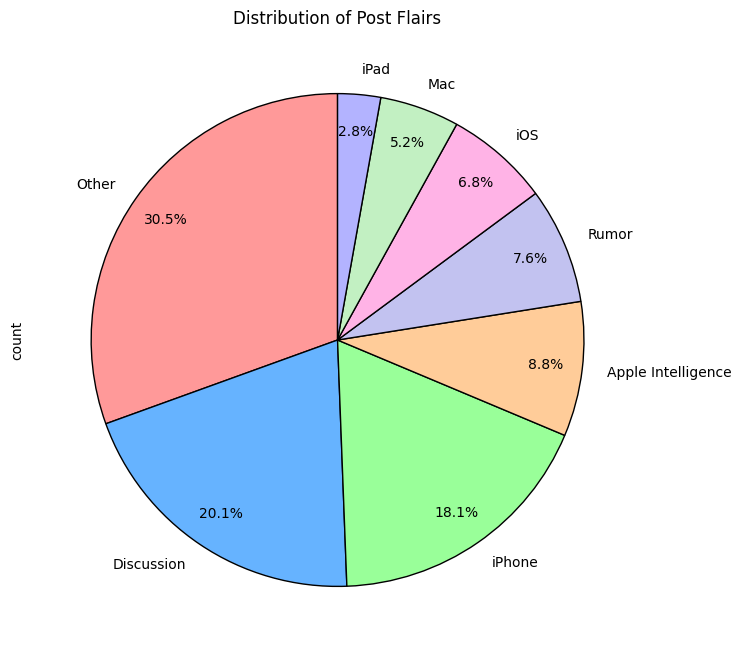

In [20]:
exclude_flair_none = top_reddit_posts[top_reddit_posts['Flair'] != 'None'].copy()

# Normalise text: remove spaces and standardise case (As some of flair have spacebar)
exclude_flair_none['Flair'] = exclude_flair_none['Flair'].str.strip()

main_flairs = [
    'iPhone',
    'Discussion',
    'iOS',
    'Mac',
    'Rumor',
    'iPad',
    'Apple Intelligence'
]

# Clean flairs
top_reddit_posts['Flair_Clean'] = exclude_flair_none['Flair'].copy()
top_reddit_posts['Flair_Clean'] = top_reddit_posts['Flair_Clean'].where(top_reddit_posts['Flair_Clean'].isin(main_flairs), other='Other')
top_reddit_posts = top_reddit_posts.copy()

# Count categories
count_flair = top_reddit_posts['Flair_Clean'].value_counts()

# Custom color palette (8 colors) 
colors = [
    '#ff9999', '#66b3ff', '#99ff99', '#ffcc99',
    '#c2c2f0', '#ffb3e6', '#c2f0c2', '#b3b3ff',
]

# Plot 
plt.figure(figsize=(11,8))
count_flair.plot(
    kind='pie',
    colors=colors[:len(count_flair)],  # Use only the number of categories
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,
    wedgeprops={'edgecolor':'black'}
)

plt.title('Distribution of Post Flairs')
plt.show()

### 3.2.2 Upvotes by Flair

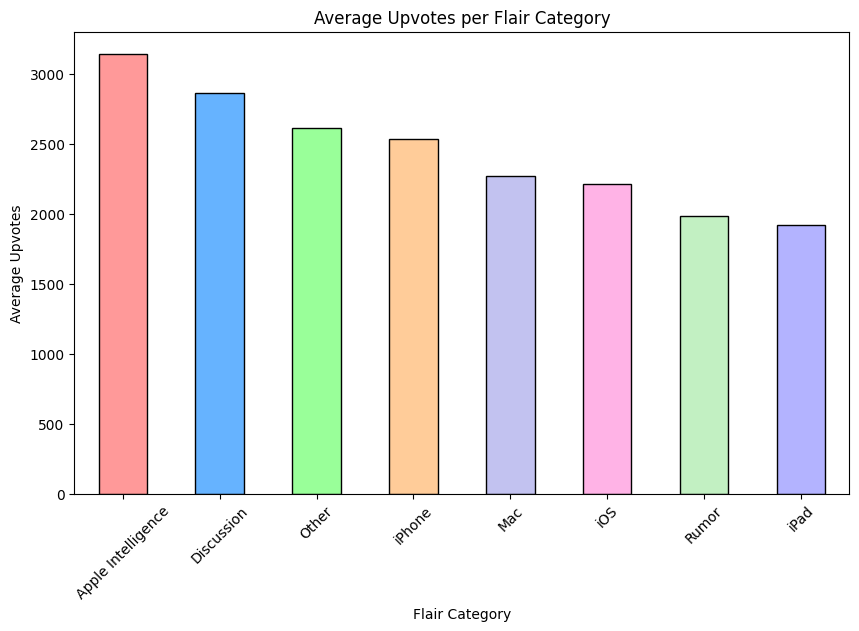

In [21]:
# Upvotes by Flair
Upvotes_By_Flair = top_reddit_posts.groupby('Flair_Clean')['Upvotes'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
colors = [
	'#ff9999',
    '#66b3ff', 
    '#99ff99', 
    '#ffcc99',
	'#c2c2f0', 
    '#ffb3e6', 
    '#c2f0c2', 
    '#b3b3ff',
]
Upvotes_By_Flair.plot(kind='bar', color=colors, edgecolor='black')

plt.title('Average Upvotes per Flair Category')
plt.xlabel('Flair Category')
plt.ylabel('Average Upvotes')
plt.xticks(rotation=45)
plt.show()

### 3.2.3 Number of Comments by Flair

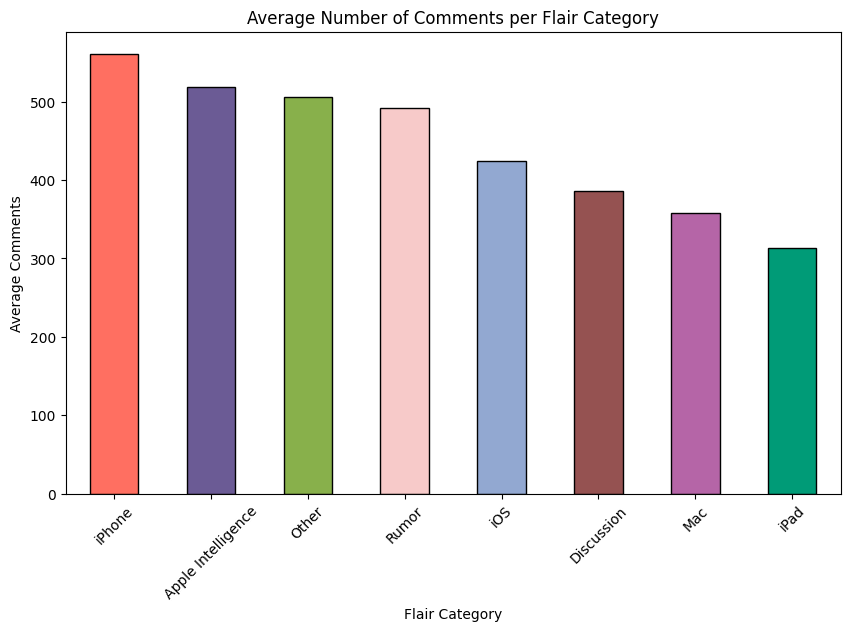

In [22]:
comments_by_flair = top_reddit_posts.groupby('Flair_Clean')['Num_Comments'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
colors = [
    '#FF6F61',  
    '#6B5B95',  
    '#88B04B',  
    '#F7CAC9',  
    '#92A8D1',  
    '#955251',  
    '#B565A7',  
    '#009B77'   
]
comments_by_flair.plot(kind='bar', color= colors, edgecolor='black')

plt.title('Average Number of Comments per Flair Category')
plt.xlabel('Flair Category')
plt.ylabel('Average Comments')
plt.xticks(rotation=45)
plt.show()

## 3.3 Text Analysis

In [23]:
#  Base English stopwords (Ex. I, You, Is)
stop_words = set(stopwords.words('english'))

#  Add custom unwanted words 
custom_stopwords = {
    'says','reddit'
    }

# Merge them together
stop_words.update(custom_stopwords)

# Clean and extract words from titles 
title_clean = top_reddit_posts['Title'].astype(str).str.lower()

### 3.3.1 Frequent Word Uses Chart

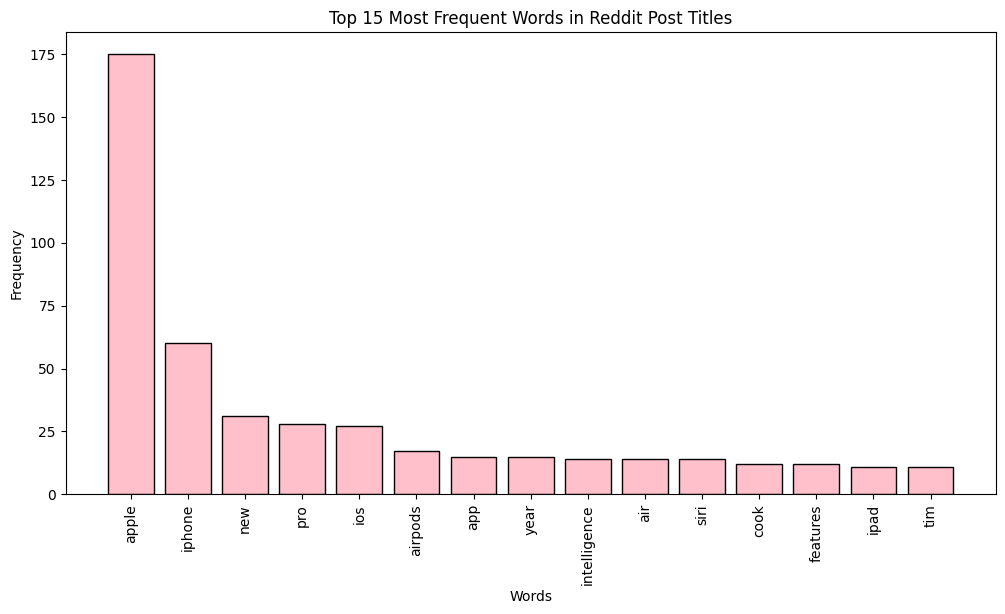

In [24]:
#  Base English stopwords (Ex. I, You, Is)
stop_words = set(stopwords.words('english'))

#  Add custom unwanted words 
custom_stopwords = {
    'says','reddit'
    }

# Merge them together
stop_words.update(custom_stopwords)

# Clean and extract words from titles 
title_clean = top_reddit_posts['Title'].astype(str).str.lower()

words = [] 

for t in title_clean:
    tokens = re.findall(r'\b[a-zA-Z]{3,}\b', t)
    tokens = [w for w in tokens if w not in stop_words]
    for w in set(tokens):   # unique per title
        words.append(w)

# Count word frequency
word_counts = Counter(words)

# Top 15 most frequent words
top_words = word_counts.most_common(15)


# Plot
plt.figure(figsize=(12, 6))
labels, counts = zip(*top_words)
plt.bar(labels, counts, 
        color= 'pink',
        edgecolor= 'black')
plt.xticks(rotation=90)
plt.title('Top 15 Most Frequent Words in Reddit Post Titles')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

### 3.3.2 Frequent Bigram Word (2-Word Combos)

In [25]:
from nltk.util import ngrams

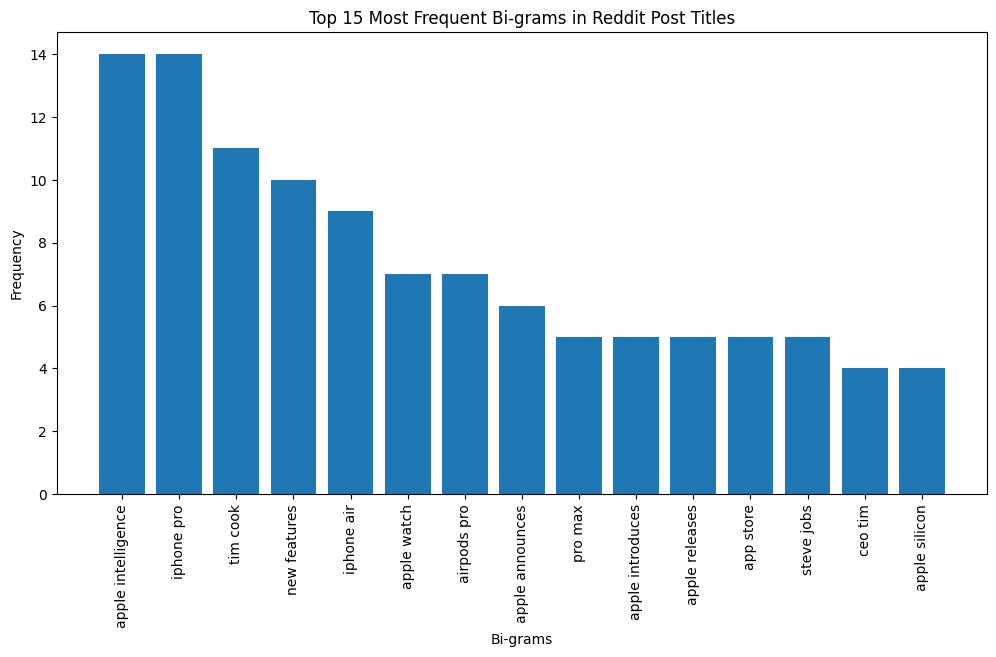

In [26]:
bigram_list = []

for t in title_clean:
    tokens = re.findall(r'\b[a-zA-Z]{3,}\b', t)
    tokens = [w for w in tokens if w not in stop_words]
    bigrams_in_title = set(ngrams(tokens, 2))
    
    for bg in bigrams_in_title:
        bigram_list.append(bg)

# Count bi-gram frequency
bigram_counts = Counter(bigram_list)

# Top 15 bi-grams
top_bigrams = bigram_counts.most_common(15)

# Prepare labels
labels, counts = zip(*top_bigrams)
labels = [' '.join(bg) for bg in labels]  # ('apple','watch') -> 'apple watch'

# Plot
plt.figure(figsize=(12, 6))
plt.bar(labels, counts)
plt.xticks(rotation=90)
plt.title('Top 15 Most Frequent Bi-grams in Reddit Post Titles')
plt.xlabel('Bi-grams')
plt.ylabel('Frequency')
plt.show()

### 3.3.3 Average Title Length Per Flair

In [27]:
top_reddit_posts['Title_Word_Count'].describe()

count    249.000000
mean      12.024096
std        5.158713
min        2.000000
25%        9.000000
50%       11.000000
75%       13.000000
max       47.000000
Name: Title_Word_Count, dtype: float64

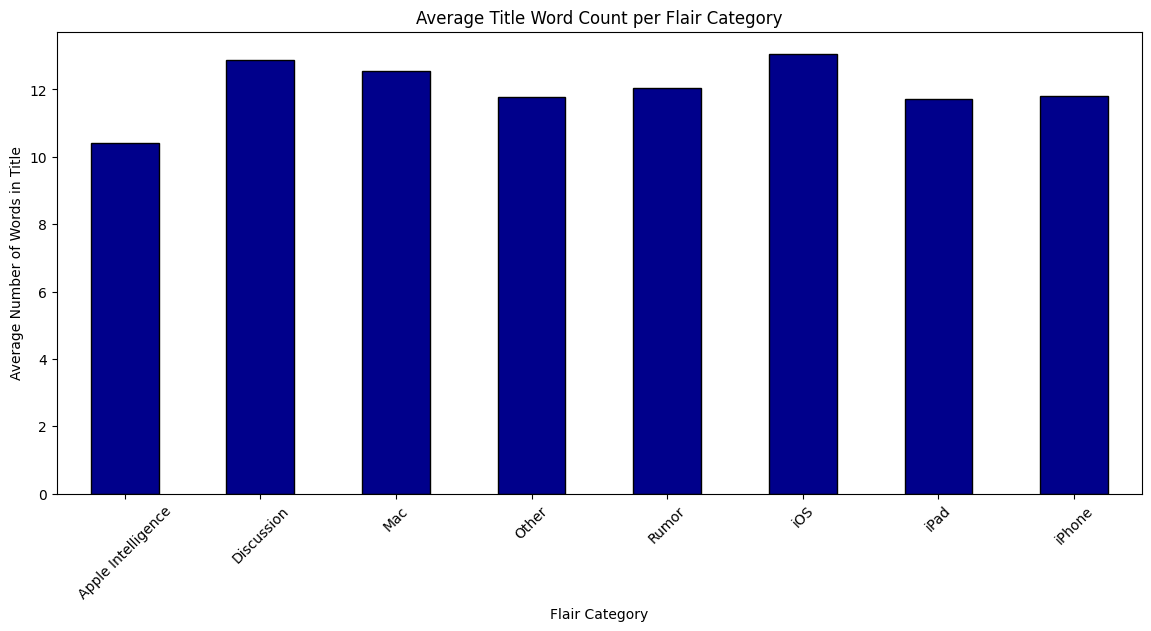

In [28]:
avg_title_length = top_reddit_posts.groupby('Flair_Clean')['Title_Word_Count'].mean()

plt.figure(figsize=(14,6))
avg_title_length.plot(kind='bar', color='darkblue', edgecolor='black')

plt.title('Average Title Word Count per Flair Category')
plt.xlabel('Flair Category')
plt.ylabel('Average Number of Words in Title')
plt.xticks(rotation=45)
plt.show()

## 3.4 Sentimental Analysis 

### 3.4.1 Sentimental Analysis Distribution

In [29]:
top_reddit_posts['Title_Sent'].value_counts()

Title_Sent
Neutral     122
Positive     71
Negative     56
Name: count, dtype: int64

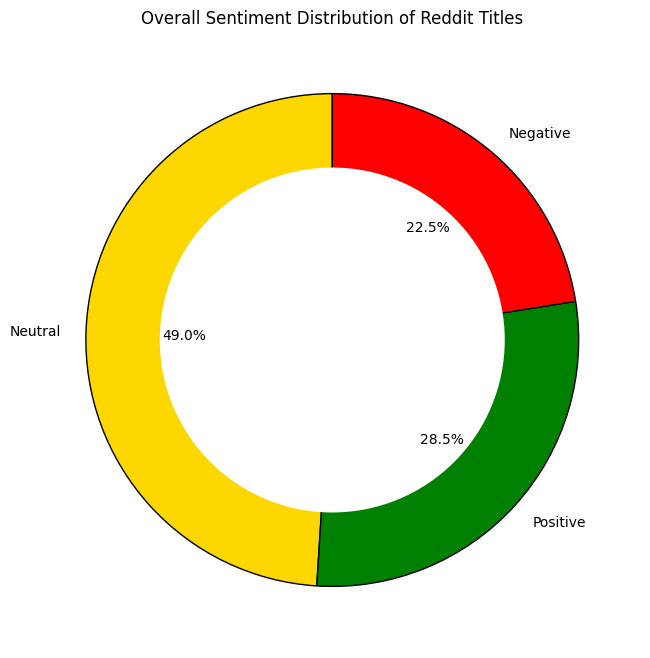

In [30]:
sentiment_counts = top_reddit_posts['Title_Sent'].value_counts()

# Colors (match your other charts)
colors = ['gold', 'green', 'red']  

plt.figure(figsize=(8,8))

# Pie chart
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'black'}
)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Overall Sentiment Distribution of Reddit Titles')
plt.show()

### 3.4.2 Relationship Between **Flair** and **Sentiment Analysis**

In [31]:
flair_sent = top_reddit_posts[top_reddit_posts['Flair'] != 'None']

# Group by Flair and Title_Sent and count posts
sentiment_flair_counts = (
    flair_sent
    .groupby(['Flair_Clean', 'Title_Sent'])
    .size()                       
    .unstack(fill_value=0)        
    .sort_index()                 
)

sentiment_flair_counts

Title_Sent,Negative,Neutral,Positive
Flair_Clean,,,
Apple Intelligence,9,3,10
Discussion,11,30,9
Mac,5,5,3
Other,10,32,23
Rumor,2,13,4
iOS,4,8,5
iPad,1,4,2
iPhone,13,21,11


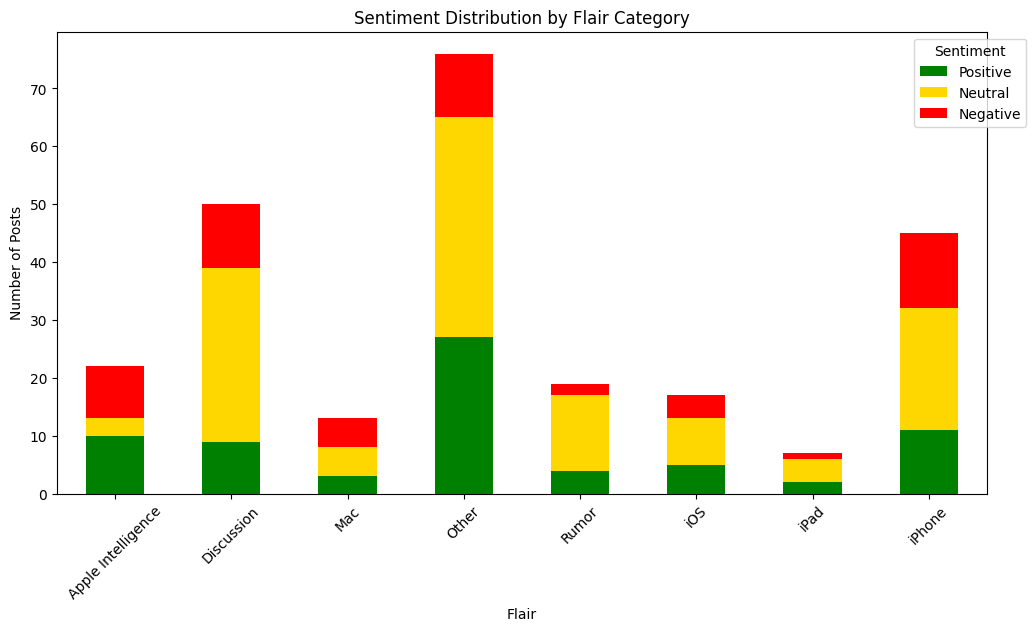

In [32]:
sentiment_by_flair = top_reddit_posts.groupby(
    ['Flair_Clean', 'Title_Sent']
).size().unstack(fill_value=0)

# Make sure columns appear in a fixed order
sentiment_by_flair = sentiment_by_flair[['Positive', 'Neutral', 'Negative']]

# Colors for each sentiment
sentiment_colors = {
    'Positive': 'green',
    'Neutral': 'gold',
    'Negative': 'red'
}

sentiment_by_flair.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    color=[sentiment_colors[col] for col in sentiment_by_flair.columns]
)

plt.title('Sentiment Distribution by Flair Category')
plt.xlabel('Flair')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1))
plt.show()

### 3.4.3 Relationship Between **Frequent Words** and **Sentiment Analysis**

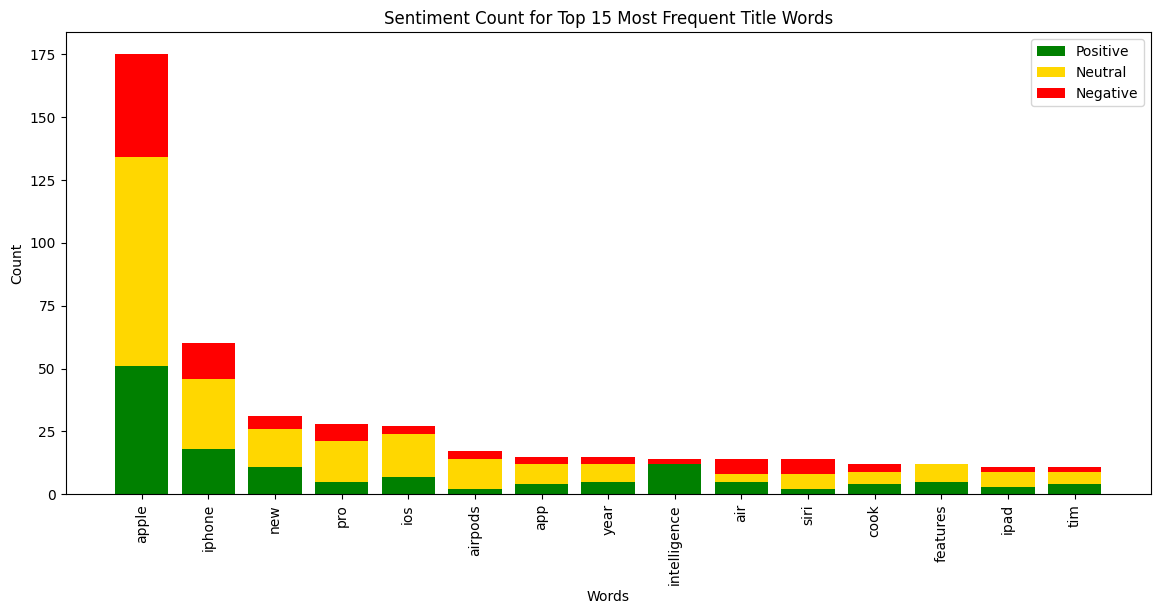

In [33]:
word_to_titles = {}  

for idx, t in enumerate(title_clean):
    unique_words = set(re.findall(r'\b[a-zA-Z]{3,}\b', t))
    for w in unique_words:
        if w not in stop_words:
            word_to_titles.setdefault(w, []).append(idx)


# Sentiment counting 
sentiment_counts = {w[0]: {'Positive': 0, 'Negative': 0, 'Neutral': 0} 
                    for w in top_words}

for word_tuple in top_words:
    word = word_tuple[0]
    rows = word_to_titles[word]  
    for r in rows:
        sent = top_reddit_posts.loc[r, 'Title_Sent']
        sentiment_counts[word][sent] += 1


# Prepare plot data 
labels = [w[0] for w in top_words]
positive = [sentiment_counts[w]['Positive'] for w in labels]
negative = [sentiment_counts[w]['Negative'] for w in labels]
neutral  = [sentiment_counts[w]['Neutral']  for w in labels]


# Plot 
plt.figure(figsize=(14,6))

plt.bar(labels, positive, label='Positive', color='green')
plt.bar(labels, neutral,  bottom=positive, label='Neutral', color='gold')
plt.bar(labels, negative, bottom=[positive[i] + neutral[i] for i in range(len(labels))], 
        label='Negative', color='red')

plt.xticks(rotation=90)
plt.title('Sentiment Count for Top 15 Most Frequent Title Words')
plt.xlabel('Words')
plt.ylabel('Count')
plt.legend()
plt.show()

### 3.4.4 Relationship Between **Frequent Bigram** and **Sentiment Analysis**

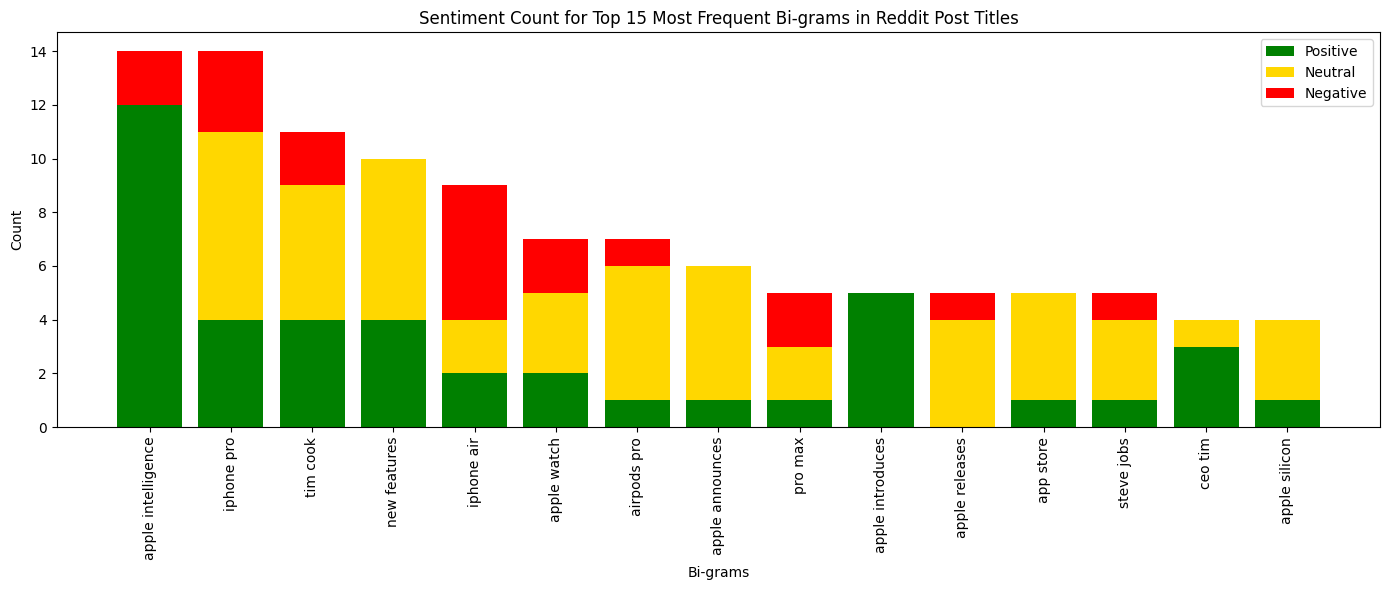

In [34]:
bigram_to_titles = {}
bigram_list = []

for idx, t in enumerate(title_clean):
    tokens = re.findall(r'\b[a-zA-Z]{3,}\b', t)
    tokens = [w for w in tokens if w not in stop_words]

    # unique bigrams per title
    bigrams_in_title = set(ngrams(tokens, 2))

    for bg in bigrams_in_title:
        bigram_list.append(bg)
        bigram_to_titles.setdefault(bg, []).append(idx)

bigram_counts = Counter(bigram_list)

top_bigrams = bigram_counts.most_common(15)

# Convert bigrams to readable text labels
bg_labels = [' '.join(bg) for bg, _ in top_bigrams]

sentiment_counts_bg = {label: {'Positive': 0, 'Negative': 0, 'Neutral': 0}
                       for label in bg_labels}

for bg, _ in top_bigrams:
    label = ' '.join(bg)
    rows = bigram_to_titles[bg]

    for r in rows:
        sent = top_reddit_posts.loc[r, 'Title_Sent']
        sentiment_counts_bg[label][sent] += 1

positive = [sentiment_counts_bg[w]['Positive'] for w in bg_labels]
neutral  = [sentiment_counts_bg[w]['Neutral']  for w in bg_labels]
negative = [sentiment_counts_bg[w]['Negative'] for w in bg_labels]


plt.figure(figsize=(14,6))

plt.bar(bg_labels, positive, label='Positive', color='green')
plt.bar(bg_labels, neutral,  bottom=positive, label='Neutral', color='gold')
plt.bar(bg_labels,
        negative,
        bottom=[positive[i] + neutral[i] for i in range(len(bg_labels))],
        label='Negative',
        color='red')

plt.xticks(rotation=90)
plt.title('Sentiment Count for Top 15 Most Frequent Bi-grams in Reddit Post Titles')
plt.xlabel('Bi-grams')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

### 3.4.5 Relationship Between **Upvotes** and **Sentimental Analysis**

In [35]:
sentiment_upvotes = top_reddit_posts.groupby('Title_Sent')['Upvotes'].agg(
    Count='count',
    Mean_Upvotes='mean',
    Median_Upvotes='median',
    Max_Upvotes='max'
)

print(sentiment_upvotes)

            Count  Mean_Upvotes  Median_Upvotes  Max_Upvotes
Title_Sent                                                  
Negative       56   2571.946429          2099.0         9872
Neutral       122   2459.114754          2060.0        13580
Positive       71   2799.028169          2003.0        11262


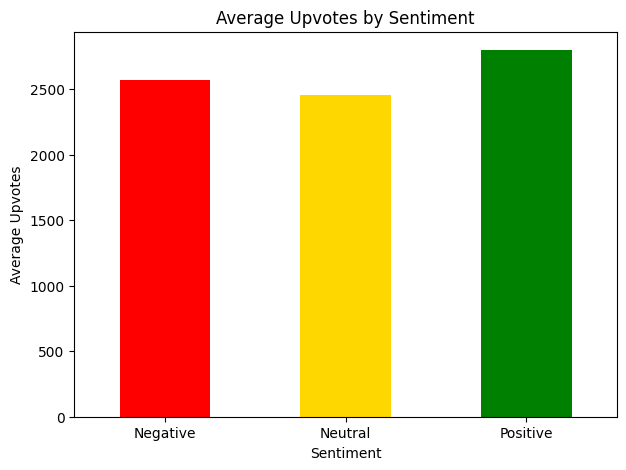

In [36]:
mean_upvotes = top_reddit_posts.groupby('Title_Sent')['Upvotes'].mean()

plt.figure(figsize=(7,5))
mean_upvotes.plot(kind='bar', color=['red','gold','green'])

plt.title('Average Upvotes by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Upvotes')
plt.xticks(rotation=0)
plt.show()

## 3.5 Time-Series (UTC)

In [37]:
top_reddit_posts['Hour_Post'] = top_reddit_posts['Created_At'].dt.hour
top_reddit_posts['Day_of_Week'] = top_reddit_posts['Created_At'].dt.day_name()


In [38]:
# old_order ['Title', 'Upvotes', 'Flair', 'Flair_Clean', 'Num_Comments', 'Body', 'Created_UTC',
#        'Post_ID', 'Created_At', 'Created_Date', 'Created_Time',
#        'Title_compound', 'Title_Sent', 'Title_Word_Count', 'Body_Word_Count',
#        'Log_Upvotes', 'Log_Num_Comments', 'Log_Body_Word_Count', 'Flair_Clean',
#        'Hour_Post', 'Day_of_Week']

new_order = ['Title', 'Upvotes', 'Log_Upvotes', 'Flair', 'Flair_Clean' ,
      'Num_Comments', 'Log_Num_Comments', 'Body', 'Created_UTC',
      'Post_ID', 'Created_At', 'Created_Date', 'Day_of_Week', 'Created_Time', 'Hour_Post',
      'Title_Word_Count', 'Body_Word_Count', 'Log_Body_Word_Count', 'Title_compound', 'Title_Sent'
        ]

top_reddit_posts = top_reddit_posts[new_order]

### 3.5.1 Post Per Hour of the Day

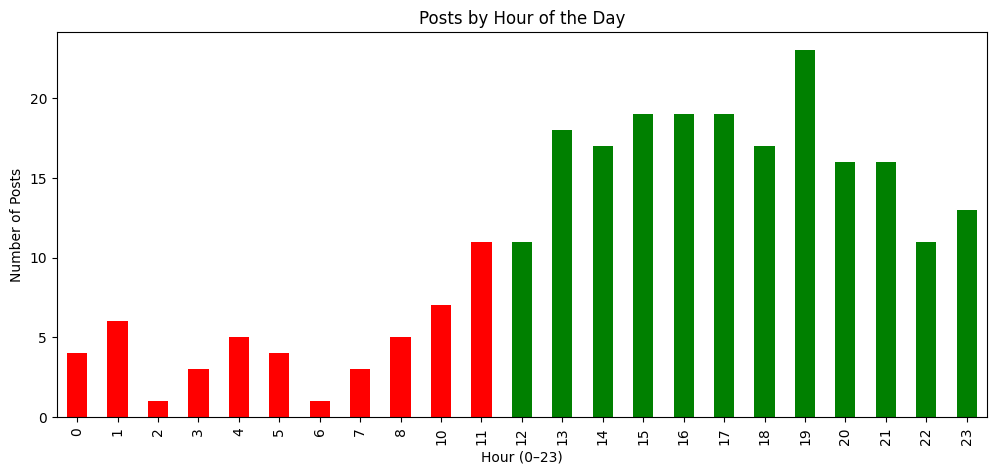

In [39]:
Posts_Per_Hour = top_reddit_posts['Hour_Post'].value_counts().sort_index()

# Choose color per hour: green for 12-23, red for 0-11
Colors_Hour = [
    'green' if h >= 12 
    else 'red' for h in Posts_Per_Hour.index
]

plt.figure(figsize=(12,5))
Posts_Per_Hour.plot(kind='bar', color= Colors_Hour)
plt.title('Posts by Hour of the Day')
plt.xlabel('Hour (0–23)') #12 AM - 11 PM
plt.ylabel('Number of Posts')
plt.show()

### 3.5.2 Post by Day of the Week

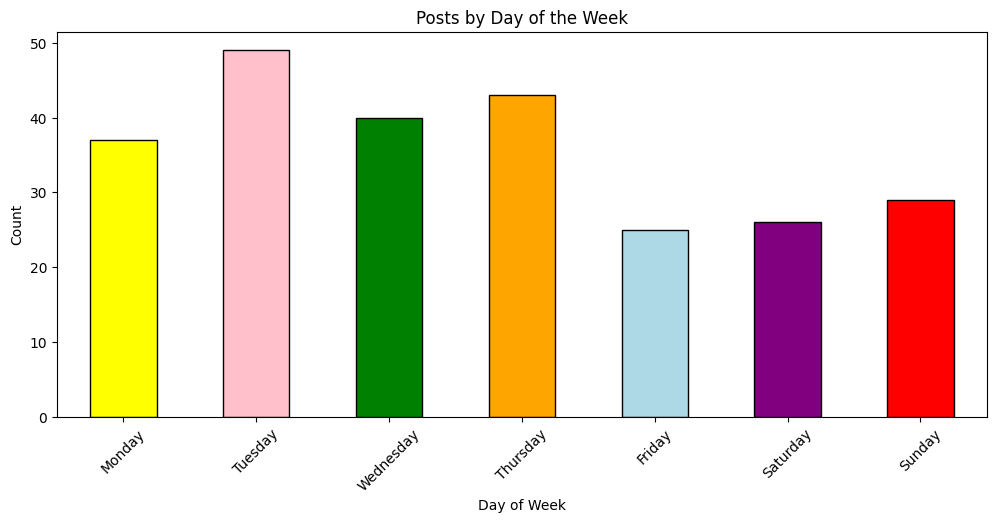

In [40]:
Posts_Per_Day_of_Week = top_reddit_posts['Day_of_Week'].value_counts().loc[
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
]

# Create color mapping for Day_of_Weeks
colors_Day_of_Week = ['yellow', 'pink', 'green', 'orange', 'lightblue', 'purple', 'red']

plt.figure(figsize=(12, 5))
Posts_Per_Day_of_Week.plot(kind='bar', color=colors_Day_of_Week, edgecolor='black')

plt.title('Posts by Day of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### 3.5.3 Post over Year

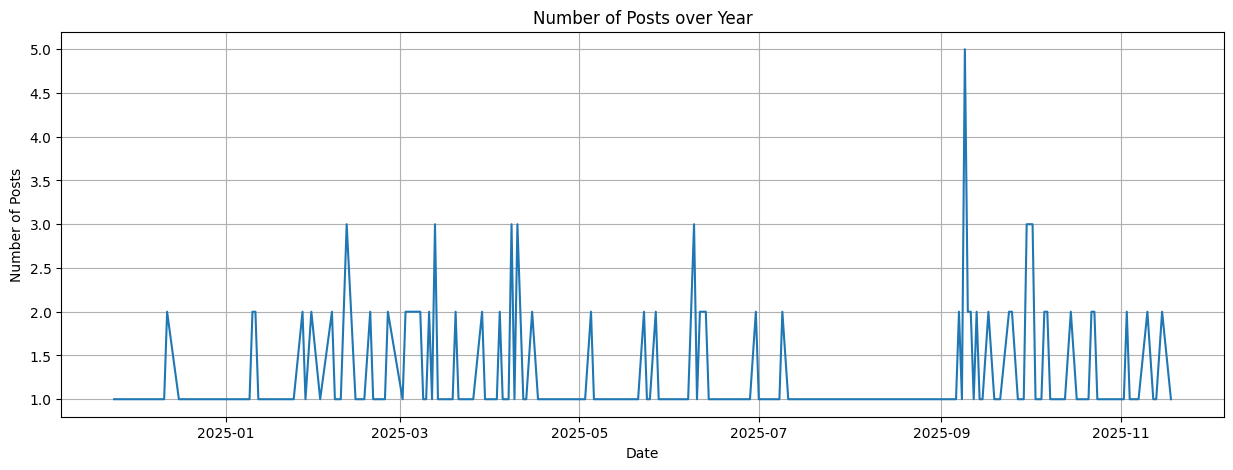

In [41]:
Posts_Per_Day = top_reddit_posts.groupby('Created_Date').size()

plt.figure(figsize=(15,5))
Posts_Per_Day.plot(kind='line')
plt.title('Number of Posts over Year')
plt.xlabel('Date')
plt.ylabel('Number of Posts')
plt.grid(True)
plt.show()

### 3.5.4 Monthly Post by Flair Trend

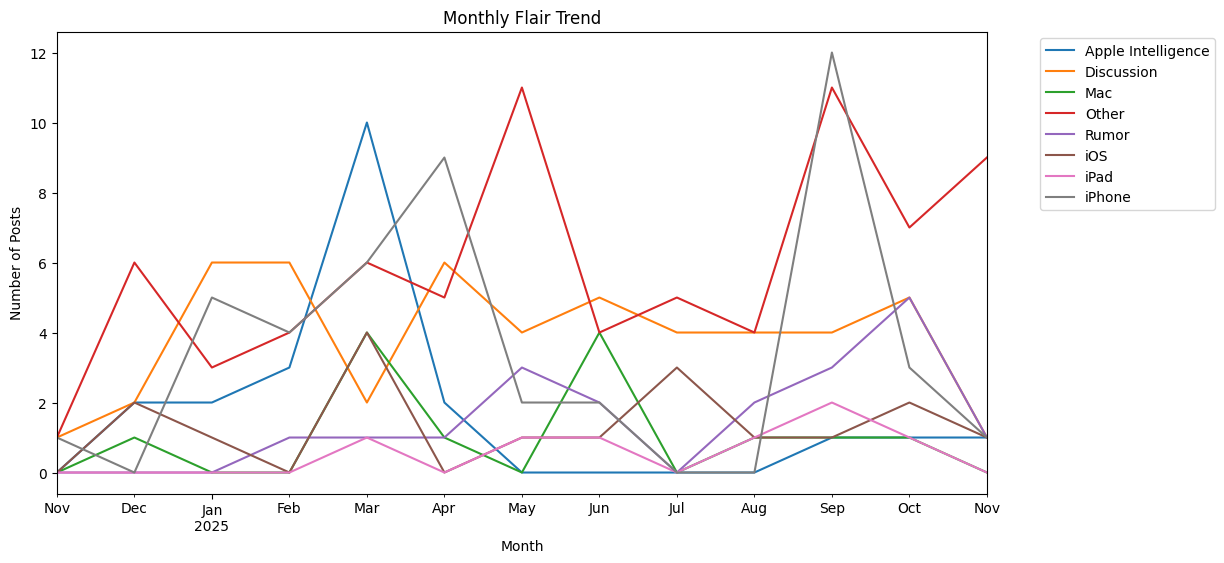

In [42]:
top_reddit_posts['Month'] = top_reddit_posts['Created_At'].dt.to_period('M').dt.to_timestamp()

Weekly_Trend = top_reddit_posts.groupby(['Month', 'Flair_Clean']).size().unstack(fill_value=0)

Weekly_Trend.plot(figsize=(12,6))
plt.title('Monthly Flair Trend')
plt.xlabel('Month')
plt.ylabel('Number of Posts')
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()

### 3.5.5 Upvotes over Year

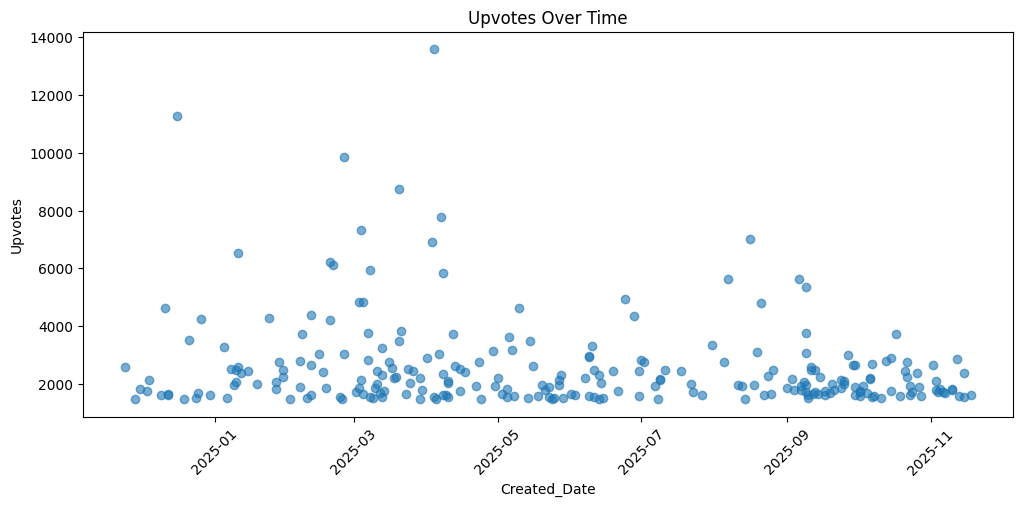

In [43]:
plt.figure(figsize=(12,5))
plt.scatter(
    top_reddit_posts['Created_Date'], 
    top_reddit_posts['Upvotes'], 
    alpha=0.6
)
plt.title('Upvotes Over Time')
plt.xlabel('Created_Date')
plt.ylabel('Upvotes')
plt.xticks(rotation=45)
plt.show()

### 3.5.6 Average Sentimental over Year

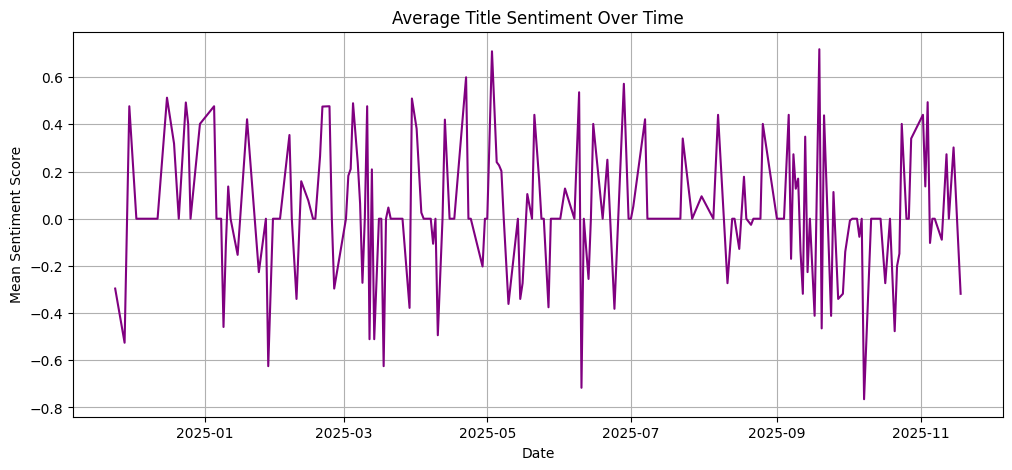

In [44]:
Sentiment_Over_Time = top_reddit_posts.groupby('Created_Date')['Title_compound'].mean()

plt.figure(figsize=(12,5))
Sentiment_Over_Time.plot(kind='line', color='purple')
plt.title('Average Title Sentiment Over Time')
plt.xlabel('Date')
plt.ylabel('Mean Sentiment Score')
plt.grid(True)
plt.show()

# Step 4 : Ask a question about your data 

## **4.1 Does the mood tone of a Reddit post (from Sentimental Analysis) influence to the engagement (Upvotes & Comments)?**

In [45]:
import seaborn as sea

### 4.1.1 Do positive posts receive more upvotes than negative or neutral mood posts? 

In [46]:
group_means = top_reddit_posts.groupby("Title_Sent")[["Upvotes"]].mean()
print(group_means)

                Upvotes
Title_Sent             
Negative    2571.946429
Neutral     2459.114754
Positive    2799.028169


/var/folders/rk/vrfbphk975xfx3m0npm7jyww0000gn/T/ipykernel_92889/2492363862.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sea.boxplot(data= top_reddit_posts, x="Title_Sent", y="Upvotes", palette=["green","gold","red"])


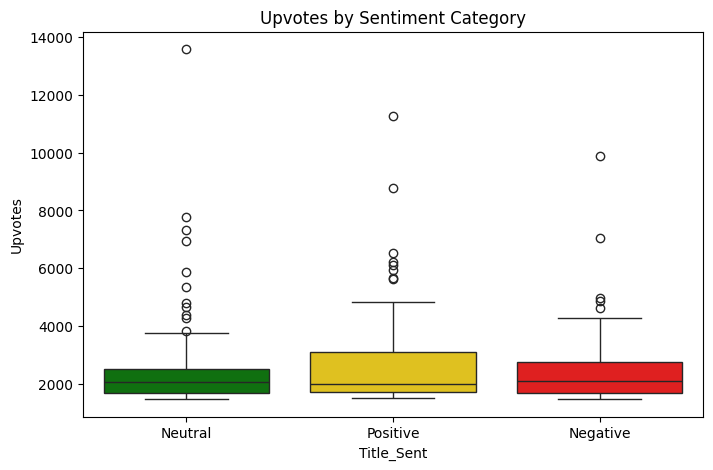

In [47]:
plt.figure(figsize=(8,5))
sea.boxplot(data= top_reddit_posts, x="Title_Sent", y="Upvotes", palette=["green","gold","red"])
plt.title("Upvotes by Sentiment Category")
plt.show()

Test for difference in means between each group whether engagement (Upvotes/Comments) differed across sentiment categories (Positive, Nuetral, Negative) by using **Kruskai-Wallis**. 

**Kruskai-Wallis** is non-parametric test due to the engagement variables were highly skewed with outliers, which is violates the ANOVA assumption (that need to be normal distrbution)

**Hypthesis Testing**
Null hypothesis (H0) is that population means are equal  
Alteranative hypothesis (H1) is that population mean are differ

In [48]:
from scipy.stats import kruskal

In [49]:
pos_upvotes = top_reddit_posts[top_reddit_posts['Title_Sent'] == 'Positive']['Upvotes']
neu_upvotes   = top_reddit_posts[top_reddit_posts['Title_Sent'] == 'Neutral']['Upvotes']
neg_upvotes  = top_reddit_posts[top_reddit_posts['Title_Sent'] == 'Negative']['Upvotes']

h_stat, p = kruskal(pos_upvotes, neu_upvotes, neg_upvotes)


print("p-value =", p)

if p <= 0.05: 
    print("Reject the null hypothesis: There is a significant between groups")
else:  
    print("Fail to reject null hypthesis: " \
    "There is NO statistically significant different between the groups")




p-value = 0.5532840017515741
Fail to reject null hypthesis: There is NO statistically significant different between the groups


### 4.1.2 Does sentiment affect how many comments a post receives?

In [50]:
num_comments_means = top_reddit_posts.groupby("Title_Sent")[["Num_Comments" ]].mean()
print(num_comments_means)

            Num_Comments
Title_Sent              
Negative      443.196429
Neutral       438.000000
Positive      557.183099


/var/folders/rk/vrfbphk975xfx3m0npm7jyww0000gn/T/ipykernel_92889/3590035566.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sea.boxplot(data=top_reddit_posts, x="Title_Sent", y="Num_Comments", palette=["green","gold","red"])


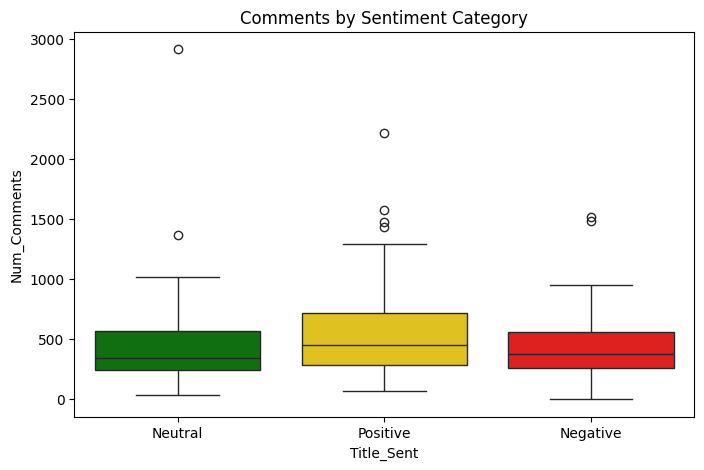

In [51]:
plt.figure(figsize=(8,5))
sea.boxplot(data=top_reddit_posts, x="Title_Sent", y="Num_Comments", palette=["green","gold","red"])
plt.title("Comments by Sentiment Category")
plt.show()

In [52]:
pos_comments = top_reddit_posts[top_reddit_posts["Title_Sent"] == "Positive"]["Num_Comments"]
neu_comments = top_reddit_posts[top_reddit_posts["Title_Sent"] == "Neutral"]["Num_Comments"]
neg_comments = top_reddit_posts[top_reddit_posts["Title_Sent"] == "Negative"]["Num_Comments"]

h_stat, p = kruskal(pos_comments, neu_comments, neg_comments)


print("p-value =", p)

if p <= 0.05: 
    print("Reject the null hypothesis: There is a significant between groups")
else:  
    print("Fail to reject null hypthesis: " \
    "There is NO statistically significant different between the groups")



p-value = 0.07807478140921198
Fail to reject null hypthesis: There is NO statistically significant different between the groups


### 4.1.3 Is compound sentiment correlated with engagement?

Measure Correlation by using **Spearman** correlation cofficients as each method captures a different type of relationship.  Spearman correlation is a non-parametric test that does not require normality and is more suitable to skewed data and outliers which are present in Number of Comments and Upvotes Distribution. In short, **Spearman** measures whether higher sentiment scores tend to be associated with higher engagment or not (Upvotes and Number of Comments)

Due to the upvotes and number of comments that are extremely skewed, using **Log_Transformation** (from 2.2.2) make it stabilise variance and make data suitable for correlation analysis. 

In [53]:
from scipy.stats import spearmanr

In [54]:
corr_up, p_up = spearmanr(top_reddit_posts['Title_compound'], top_reddit_posts['Log_Upvotes']) # corr_up --> Spearman correlation coefficiant, p_up --> p-value 
corr_com, p_com = spearmanr(top_reddit_posts['Title_compound'], top_reddit_posts['Log_Num_Comments'])
print("Sentiment vs Upvotes:", corr_up, p_up)
print("Sentiment vs Comments:", corr_com, p_com)

Sentiment vs Upvotes: 0.026510743636251704 0.6771899571158888
Sentiment vs Comments: 0.10751745765038725 0.09046098575821798


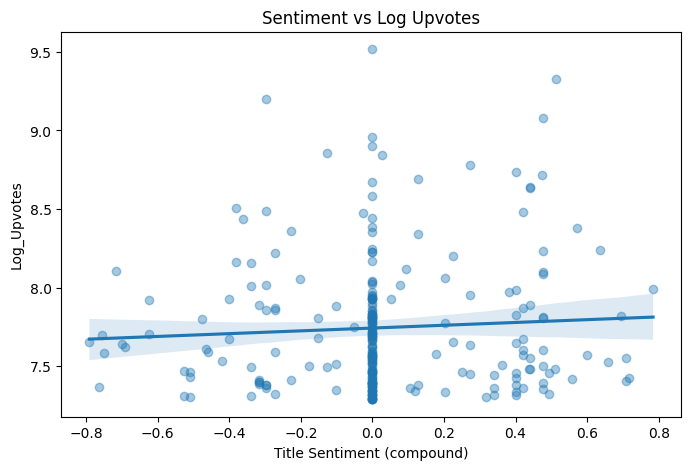

In [55]:
plt.figure(figsize=(8,5))
sea.regplot(x='Title_compound', y='Log_Upvotes', data=top_reddit_posts,
            scatter_kws={'alpha':0.4})
plt.title("Sentiment vs Log Upvotes")
plt.xlabel("Title Sentiment (compound)")
plt.ylabel("Log_Upvotes")
plt.show()


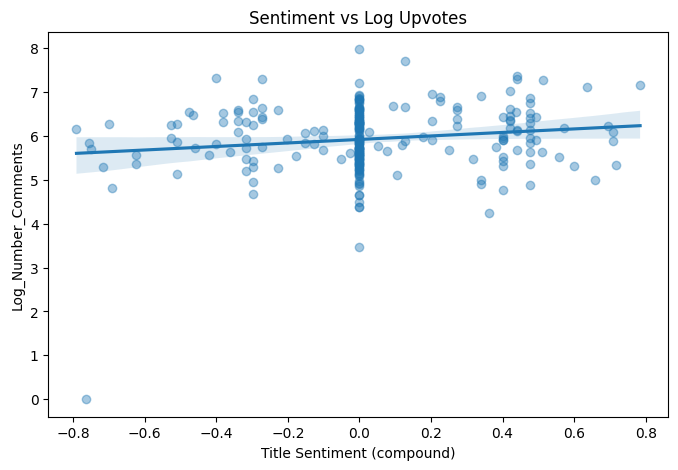

In [56]:
plt.figure(figsize=(8,5))
sea.regplot(x='Title_compound', y='Log_Num_Comments', data=top_reddit_posts,
            scatter_kws={'alpha':0.4})
plt.title("Sentiment vs Log Upvotes")
plt.xlabel("Title Sentiment (compound)")
plt.ylabel("Log_Number_Comments")
plt.show()


### 4.1.4 Does sentiment remain significant afteer controlling for other factors?

In [57]:
top_reddit_posts['Log_Upvotes'] = np.log1p(top_reddit_posts['Upvotes'])

In [58]:
%pip install statsmodels


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [59]:
import statsmodels.api as sm
import pandas as pd

df = top_reddit_posts.copy()

# Select features
X = df[['Title_compound', 'Title_Word_Count', 'Log_Num_Comments']]
X = sm.add_constant(X)

y = df['Log_Upvotes']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Log_Upvotes   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.141
Method:                 Least Squares   F-statistic:                     14.63
Date:                Sun, 23 Nov 2025   Prob (F-statistic):           8.59e-09
Time:                        01:14:25   Log-Likelihood:                -117.49
No. Observations:                 249   AIC:                             243.0
Df Residuals:                     245   BIC:                             257.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                6.3513      0.216  